In [19]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import mlflow
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from itertools import product
from datetime import datetime
from torchinfo import summary


In [35]:
if torch.backends.mps.is_available():
    device = torch.device("mps")      # Mac GPU (Apple Silicon)
elif torch.cuda.is_available():
    device = torch.device("cuda")     # Nvidia GPU
else:
    device = torch.device("cpu")


print(f"Using device: {device}")


random_seed = 42 
RANDOM_SEED = random_seed   
torch.manual_seed(random_seed)
np.random.seed(random_seed)
random.seed(random_seed)


# Make sure mlflow ui is running: run 'mlflow ui' in terminal first
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("Scoring_of_movement")
mlflow.enable_system_metrics_logging()

Using device: mps


## Data preprocess

In [21]:
def load_and_reshape_all_files(data_dir, n_frames=30, n_features=39):
    """Load all CSV files and reshape them"""
    all_X = []
    all_y = []
    
    for csv_file in os.listdir(data_dir):
        if csv_file.endswith(".csv"):
            df = pd.read_csv(os.path.join(data_dir, csv_file))
            y = df["target"].values
            X_flat = df.drop(columns=["target"]).values
            
            # Reshape
            X = X_flat.reshape(-1, n_frames, n_features)
            
            all_X.append(X)
            all_y.append(y)
    
    # Concatenate all samples
    X_all = np.concatenate(all_X, axis=0)
    y_all = np.concatenate(all_y, axis=0)
    
    return X_all, y_all


def mirror_pose_data(X):
    """
    Mirror pose data by swapping left and right body parts.
    
    Args:
        X: numpy array of shape (n_samples, n_frames, 39)
    
    Returns:
        X_mirrored: mirrored version with same shape
    """
    # Define mapping for left-right pairs
    # Each body part has 3 coordinates (x, y, z)
    # Indices: 0-2: head, 3-5: left_shoulder, 6-8: left_elbow, 9-11: right_shoulder, etc.
    
    # Left and right body part index pairs (3 coordinates each)
    left_right_pairs = [
        (3, 9),   # left_shoulder (3-5) <-> right_shoulder (9-11)
        (6, 12),  # left_elbow (6-8) <-> right_elbow (12-14)
        (15, 18), # left_hand (15-17) <-> right_hand (18-20)
        (21, 24), # left_hip (21-23) <-> right_hip (24-26)
        (27, 30), # left_knee (27-29) <-> right_knee (30-32)
        (33, 36), # left_foot (33-35) <-> right_foot (36-38)
    ]
    
    X_mirrored = X.copy()
    
    for sample in range(X.shape[0]):
        for frame in range(X.shape[1]):
            for left_start, right_start in left_right_pairs:
                # Swap x, y, z coordinates (3 values per body part)
                left_indices = slice(left_start, left_start + 3)
                right_indices = slice(right_start, right_start + 3)
                
                # Swap left and right
                temp = X_mirrored[sample, frame, left_indices].copy()
                X_mirrored[sample, frame, left_indices] = X_mirrored[sample, frame, right_indices]
                X_mirrored[sample, frame, right_indices] = temp
    
    return X_mirrored

def augment_with_noise(X, noise_std=0.005):
    noise = np.random.normal(0, noise_std, X.shape)
    return X + noise



In [22]:
# Load data
data_dir = "../../MainProject/Data/mediapipe_score_fixed_c"
X, y = load_and_reshape_all_files(data_dir, n_frames=30, n_features=39)
print(f"Original samples: {X.shape[0]}")

# Ensure initial data is contiguous
X = np.ascontiguousarray(X)
y = np.ascontiguousarray(y)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Apply mirror augmentation
print("Applying mirror augmentation...")
X_train_mirrored = mirror_pose_data(X_train)
y_train_mirrored = y_train.copy()

# Ensure mirrored data is contiguous
X_train_mirrored = np.ascontiguousarray(X_train_mirrored)
y_train_mirrored = np.ascontiguousarray(y_train_mirrored)

# Concatenate original and mirrored
X_train_augmented = np.concatenate([X_train, X_train_mirrored], axis=0)
y_train_augmented = np.concatenate([y_train, y_train_mirrored], axis=0)

# Ensure concatenated data is contiguous
X_train_augmented = np.ascontiguousarray(X_train_augmented)
y_train_augmented = np.ascontiguousarray(y_train_augmented)

# Add noise augmentation
X_noisy = augment_with_noise(X_train_augmented)
X_noisy = np.ascontiguousarray(X_noisy)

X_train_final = np.concatenate([X_train_augmented, X_noisy], axis=0)
y_train_final = np.concatenate([y_train_augmented, y_train_augmented], axis=0)

# Ensure final data is contiguous
X_train_final = np.ascontiguousarray(X_train_final)
y_train_final = np.ascontiguousarray(y_train_final)

print(f"Final training samples: {X_train_final.shape[0]}")

# Standardize features
scaler = StandardScaler()
X_train_flat = X_train_final.reshape(-1, X_train_final.shape[-1])
X_test_flat = X_test.reshape(-1, X_test.shape[-1])

X_train_flat = scaler.fit_transform(X_train_flat)
X_test_flat = scaler.transform(X_test_flat)

# Reshape back
X_train = X_train_flat.reshape(X_train_final.shape)
X_test = X_test_flat.reshape(X_test.shape)

# Ensure after reshape they are contiguous
X_train = np.ascontiguousarray(X_train)
X_test = np.ascontiguousarray(X_test)

# Add channel dimension for CNN (batch, channels, frames, features)
X_train = X_train[:, np.newaxis, :, :]
X_test = X_test[:, np.newaxis, :, :]

y_train = y_train_final
y_test = np.ascontiguousarray(y_test)

# Final contiguity check
X_train = np.ascontiguousarray(X_train)
X_test = np.ascontiguousarray(X_test)
y_train = np.ascontiguousarray(y_train)
y_test = np.ascontiguousarray(y_test)

# CRITICAL: Correct order - (frames, features)
input_shape = (30, 39)  # 30 frames, 39 features

print(f"Final X_train shape: {X_train.shape}")  # Should be (N, 1, 30, 39)
print(f"Final X_test shape: {X_test.shape}")    # Should be (N, 1, 30, 39)
print(f"input_shape: {input_shape}")

# Verify contiguity
print(f"X_train is contiguous: {X_train.flags['C_CONTIGUOUS']}")
print(f"X_test is contiguous: {X_test.flags['C_CONTIGUOUS']}")
print(f"y_train is contiguous: {y_train.flags['C_CONTIGUOUS']}")
print(f"y_test is contiguous: {y_test.flags['C_CONTIGUOUS']}")

Original samples: 174
Applying mirror augmentation...
Final training samples: 556
Final X_train shape: (556, 1, 30, 39)
Final X_test shape: (35, 1, 30, 39)
input_shape: (30, 39)
X_train is contiguous: True
X_test is contiguous: True
y_train is contiguous: True
y_test is contiguous: True


## CNN Model

In [57]:
class SquatClassifierCNN(nn.Module):
    def __init__(self, input_dim, dropout_rate=0.4):
        super().__init__()
        frames, features = input_dim
        
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(dropout_rate)
        )
        
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(dropout_rate)
        )
        
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Dropout2d(dropout_rate)
        )
        
        # NO Flatten here - we'll do manual reshape in forward
        self.fc1 = nn.Linear(128, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        
    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        # CRITICAL: Use reshape, NOT view, NOT Flatten
        x = x.reshape(x.shape[0], -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

def build_cnn_model(config, input_dim):
    return SquatClassifierCNN(
        input_dim=input_dim, 
        dropout_rate=config.get("dropout", 0.4)
    )

# Test the model
print("Testing model...")
test_model = SquatClassifierCNN(input_dim=(30, 39))
test_input = torch.randn(4, 1, 30, 39)
test_output = test_model(test_input)
print(f"✓ Model works! Input: {test_input.shape} -> Output: {test_output.shape}")

Testing model...
✓ Model works! Input: torch.Size([4, 1, 30, 39]) -> Output: torch.Size([4, 1])


In [58]:
class CompactSquatCNN(nn.Module):
    def __init__(self, input_dim, dropout_rate=0.4):
        super().__init__()
        frames, features = input_dim
        
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(dropout_rate)
        )
        
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(dropout_rate)
        )
        
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Dropout2d(dropout_rate)
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(32, 1)
        )
        
    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = x.reshape(x.size(0), -1)
        x = self.classifier(x)
        return x

def build_compact_squat_cnn_model(config, input_dim):
    return CompactSquatCNN(
        input_dim=input_dim, 
        dropout_rate=config.get("dropout", 0.4)
    )

## Compute metrics and train model

In [29]:
# ── compute_metrics: regression ─────────────────────────────────────────────
def compute_metrics(y_true, y_pred):
    """y_true and y_pred are 1-D numpy arrays."""
    return {
        "mse":  float(mean_squared_error(y_true, y_pred)),
        "mae":  float(mean_absolute_error(y_true, y_pred)),
        "r2":   float(r2_score(y_true, y_pred)),
        "bias": float(np.mean(y_pred - y_true)),
    }


def train_one_model(model, config, x_train, y_train, x_val, y_val, loss_fn,
                    run_name=None):
    """
    Regression trainer.
    y_train / y_val: float tensors of shape (N, 1)
    Logs every epoch to MLflow (train_loss, val_loss, val_mae, val_r2).
    Returns (best_val_mse, model, history)
    """
    # REMOVE these lines - they are wrong!
    # x_train = np.ascontiguousarray(x_train)
    # y_train = np.ascontiguousarray(y_train)

    device = x_train.device
    model = model.to(device)

    # Use weight_decay from config if present
    weight_decay = config.get("weight_decay", 0.0)
    optimizer = optim.Adam(model.parameters(), lr=config["lr"], weight_decay=weight_decay)
    
    epochs = config["epochs"]
    best_val_mse = float("inf")
    best_state = None
    patience = 200
    epochs_no_improve = 0

    history = {"train_loss": [], "val_loss": [], "val_mae": [], "val_r2": []}

    with mlflow.start_run(run_name=run_name, nested=True):
        mlflow.log_params(config)

        for epoch in range(epochs):
            # Train
            model.train()
            optimizer.zero_grad()
            preds = model(x_train)
            train_loss = loss_fn(preds, y_train)
            train_loss.backward()
            optimizer.step()

            # Validate
            model.eval()
            with torch.no_grad():
                val_preds = model(x_val)
                val_loss = loss_fn(val_preds, y_val)

                y_val_np = y_val.cpu().numpy().flatten()
                yp_np = val_preds.cpu().numpy().flatten()

                val_mae = float(mean_absolute_error(y_val_np, yp_np))
                val_r2 = float(r2_score(y_val_np, yp_np))

            tl = train_loss.item()
            vl = val_loss.item()
            history["train_loss"].append(tl)
            history["val_loss"].append(vl)
            history["val_mae"].append(val_mae)
            history["val_r2"].append(val_r2)

            # Log every epoch to MLflow
            mlflow.log_metrics({
                "train_loss": tl,
                "val_loss": vl,
                "val_mae": val_mae,
                "val_r2": val_r2,
            }, step=epoch)

            # Early stopping on val MSE (lower = better)
            if vl < best_val_mse:
                best_val_mse = vl
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1

            if epochs_no_improve >= patience:
                print(f"    Early stop at epoch {epoch}")
                break

        mlflow.log_metric("best_val_mse", best_val_mse)

    if best_state is not None:
        model.load_state_dict(best_state)

    return best_val_mse, model, history

def cross_validate_model(config, X, y, loss_fn, input_dim, n_splits=5):
    """K-Fold cross-validation for regression."""
    # Ensure input data is contiguous
    X = np.ascontiguousarray(X)
    y = np.ascontiguousarray(y)
    
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)
    fold_mse_scores = []

    device = torch.device("cpu")  # Force CPU to avoid MPS issues
    print(f"  Using device: {device}")

    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        print(f"  Fold {fold + 1}/{n_splits}...")

        X_train_f = np.ascontiguousarray(X[train_idx])
        X_val_f = np.ascontiguousarray(X[val_idx])
        y_train_f = np.ascontiguousarray(y[train_idx])
        y_val_f = np.ascontiguousarray(y[val_idx])

        # Convert to tensors
        X_train_t = torch.from_numpy(X_train_f).float().contiguous().to(device)
        X_val_t = torch.from_numpy(X_val_f).float().contiguous().to(device)
        y_train_t = torch.from_numpy(y_train_f).float().contiguous().to(device).unsqueeze(1)
        y_val_t = torch.from_numpy(y_val_f).float().contiguous().to(device).unsqueeze(1)

        model = build_cnn_model(config, input_dim).to(device)

        val_mse, _, _ = train_one_model(
            model, config,
            X_train_t, y_train_t,
            X_val_t, y_val_t,
            loss_fn,
            run_name=f"fold-{fold+1}"
        )
        fold_mse_scores.append(val_mse)
        
        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return {
        "cv_mean_mse": float(np.mean(fold_mse_scores)),
        "mse_std": float(np.std(fold_mse_scores)),
        "fold_scores": fold_mse_scores,
    }

## Save best model

In [25]:
def load_champion_info(metadata_dir):
    path = os.path.join(metadata_dir, "champion_info.json")
    if not os.path.exists(path):
        return None
    with open(path, "r") as f:
        return json.load(f)


def save_champion_model(champion_dir, metadata_dir, model, model_name,
                        mse, mae, r2, hyperparameters):
    os.makedirs(champion_dir, exist_ok=True)
    os.makedirs(metadata_dir, exist_ok=True)
    torch.save(model.state_dict(), os.path.join(champion_dir, "champion_model.pt"))
    info = {
        "model_name":     model_name,
        "saved_at":       datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "mse":            float(mse),
        "mae":            float(mae),
        "r2":             float(r2),
        "hyperparameters": hyperparameters,
    }
    with open(os.path.join(metadata_dir, "champion_info.json"), "w") as f:
        json.dump(info, f, indent=2)
    print("New champion model saved!")
    return True


def update_champion(metadata_dir, champion_dir, model, model_name,
                    mse, mae, r2, hyperparameters):
    current = load_champion_info(metadata_dir)
    if current is None:
        print("No champion found --> saving first model")
        return save_champion_model(champion_dir, metadata_dir, model, model_name,
                                   mse, mae, r2, hyperparameters)
    elif mse < current["mse"]:   # lower MSE = better
        print(f"New model is better (MSE {mse:.4f} < {current['mse']:.4f})")
        return save_champion_model(champion_dir, metadata_dir, model, model_name,
                                   mse, mae, r2, hyperparameters)
    else:
        print(f"Model NOT better (MSE {mse:.4f} >= {current['mse']:.4f})")
        return False


In [37]:
# ── Grid search with outer MLflow run ────────────────────────────────────────
param_grid  = {"lr": [0.005], "dropout": [0.3], "epochs": [250], "weight_decay": [0.0001]}
trial       = 0
best_mse    = float("inf")   # lower is better for regression
best_config = None

loss_func = nn.MSELoss()
loss_func = nn.HuberLoss(delta=0.5)

print("Starting Grid Search...")
print("=" * 60)

for values in product(param_grid["lr"], param_grid["dropout"], param_grid["epochs"], param_grid["weight_decay"]):
    config = {"lr": values[0], "dropout": values[1], "epochs": values[2], "weight_decay": values[3]}
    print(f"\nTrial {trial + 1}: {config}")

    with mlflow.start_run(run_name=f"trial-{trial+1}_lr{config['lr']}_ep{config['epochs']}"):
        mlflow.log_params(config)

        results  = cross_validate_model(config, X_train, y_train, loss_func, input_shape, n_splits=10)
        mse_score = results["cv_mean_mse"]

        mlflow.log_metrics({
            "cv_mean_mse": mse_score,
            "cv_mse_std":  results["mse_std"],
        })

    print(f"  CV mean MSE: {mse_score:.4f} +- {results['mse_std']:.4f}")

    if mse_score < best_mse:
        best_mse    = mse_score
        best_config = config
        print("  *** NEW BEST! ***")

    trial += 1

print("\n" + "=" * 60)
print(f"Best configuration: {best_config}")
print(f"Best cross-validation MSE: {best_mse:.4f}")
print("\nRun `mlflow ui` in your terminal to view results.")


2026/05/25 20:08:58 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/05/25 20:08:58 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/05/25 20:08:58 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/05/25 20:08:58 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.


Starting Grid Search...

Trial 1: {'lr': 0.005, 'dropout': 0.3, 'epochs': 250, 'weight_decay': 0.0001}
  Using device: cpu
  Fold 1/10...


2026/05/25 20:10:04 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/05/25 20:10:04 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!
2026/05/25 20:10:04 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/05/25 20:10:04 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.


🏃 View run fold-1 at: http://127.0.0.1:5000/#/experiments/2/runs/395b05d376ca49eb93dbd2271cc943a9
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2
  Fold 2/10...


2026/05/25 20:10:05 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/05/25 20:10:05 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!
2026/05/25 20:10:05 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/05/25 20:10:05 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


🏃 View run fold-2 at: http://127.0.0.1:5000/#/experiments/2/runs/0a3f13061c3641019946acd2b037b139
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2
🏃 View run trial-1_lr0.005_ep250 at: http://127.0.0.1:5000/#/experiments/2/runs/50bb5460c7c342eabb3b1c78c057d586
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2


KeyboardInterrupt: 

2026/05/25 20:22:01 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/05/25 20:22:01 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/05/25 20:22:01 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/05/25 20:22:01 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/05/25 20:22:15 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/05/25 20:22:15 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!
2026/05/25 20:22:15 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/05/25 20:22:15 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


🏃 View run final_model_inner at: http://127.0.0.1:5000/#/experiments/2/runs/8ec0199ac8f34a538c9f585836008412
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2
🏃 View run final_model at: http://127.0.0.1:5000/#/experiments/2/runs/98fd539e00604b46b46b7cbc9d3688d4
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2
Final model validation MSE: 0.0911
Layer (type:depth-idx)                   Output Shape              Param #
SquatClassifierCNN                       [1, 1]                    --
├─Sequential: 1-1                        [1, 32, 15, 19]           --
│    └─Conv2d: 2-1                       [1, 32, 30, 39]           320
│    └─BatchNorm2d: 2-2                  [1, 32, 30, 39]           64
│    └─ReLU: 2-3                         [1, 32, 30, 39]           --
│    └─MaxPool2d: 2-4                    [1, 32, 15, 19]           --
│    └─Dropout2d: 2-5                    [1, 32, 15, 19]           --
├─Sequential: 1-2                        [1, 64, 7, 9]             

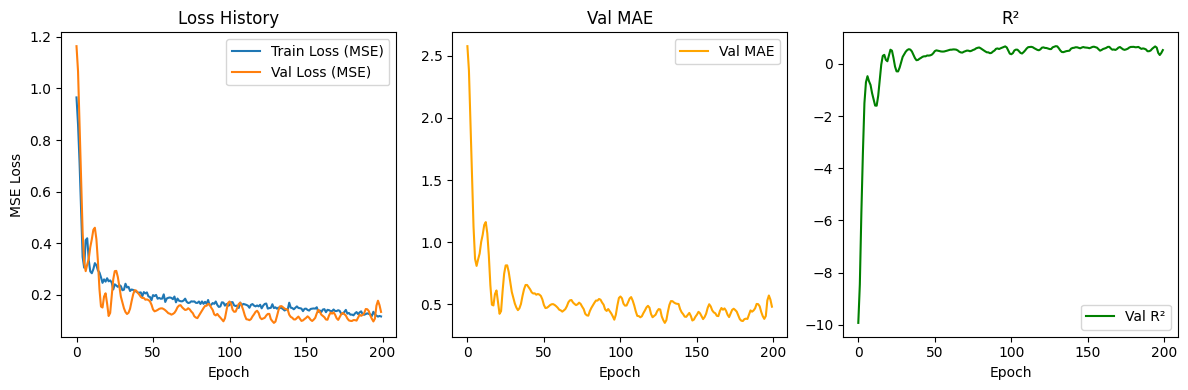

In [ ]:
# Add channel dimension for CNN: (N, frames, features) → (N, 1, frames, features)
best_config = {
    "lr": 0.005,
    "dropout": 0.25,
    "epochs": 200,
    "weight_decay": 0.0001
}


X_train_cnn = X_train
X_test_cnn  = X_test

X_train_t = torch.from_numpy(np.ascontiguousarray(X_train_cnn)).float().contiguous().to(device)
X_val_t   = torch.from_numpy(np.ascontiguousarray(X_test_cnn)).float().contiguous().to(device)
y_train_t = torch.from_numpy(y_train).float().unsqueeze(1).contiguous().to(device)
y_val_t   = torch.from_numpy(y_test).float().unsqueeze(1).contiguous().to(device)

final_model = build_cnn_model(best_config, input_shape)

with mlflow.start_run(run_name="final_model"):
    val_mse, final_model, history = train_one_model(
        final_model, best_config, X_train_t, y_train_t, X_val_t, y_val_t,
        loss_func, run_name="final_model_inner"
    )

print(f"Final model validation MSE: {val_mse:.4f}")
print(summary(final_model, input_size=(1, 1, input_shape[0], input_shape[1])))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="Train Loss (MSE)")
axes[0].plot(history["val_loss"],   label="Val Loss (MSE)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE Loss")
axes[0].legend(); axes[0].set_title("Loss History")

axes[1].plot(history["val_mae"], label="Val MAE", color="orange")
axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].set_title("Val MAE")

axes[2].plot(history["val_r2"],  label="Val R²",  color="green")
axes[2].set_xlabel("Epoch")
axes[2].legend(); axes[2].set_title("R²")

plt.tight_layout()
plt.show()


TEST SET EVALUATION (Regression)
Test MSE:   0.2168
Test RMSE:  0.4656
Test MAE:   0.3501
Test R²:    0.6761
Bias:       +0.0233  (positive = over-predicts)


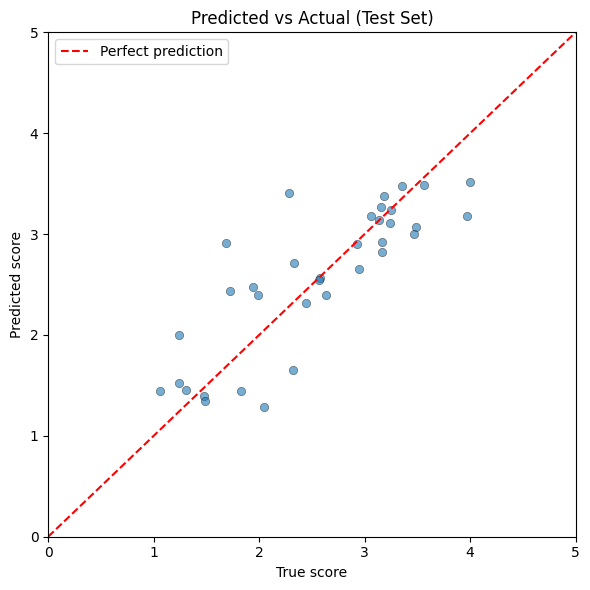

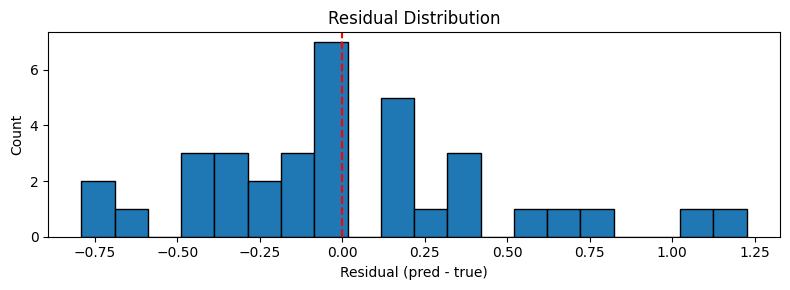

Model NOT better (MSE 0.2168 >= 0.2013)

❌ Modell var inte bättre än nuvarande champion


In [62]:
# ── Evaluate on held-out test set ────────────────────────────────────────────
X_test_cnn = X_test
X_test_t   = torch.from_numpy(np.ascontiguousarray(X_test_cnn)).float().contiguous().to(device)
y_test_t   = torch.from_numpy(y_test).float().unsqueeze(1).contiguous().to(device)

final_model.eval().to(device)

with torch.no_grad():
    y_pred_t  = final_model(X_test_t)          # (N, 1)
    test_loss = loss_func(y_pred_t, y_test_t).item()

y_test_np = y_test_t.cpu().numpy().flatten()
y_pred_np = y_pred_t.cpu().numpy().flatten()

test_mse  = mean_squared_error(y_test_np, y_pred_np)
test_mae  = mean_absolute_error(y_test_np, y_pred_np)
test_r2   = r2_score(y_test_np, y_pred_np)
test_bias = float(np.mean(y_pred_np - y_test_np))

print("\n" + "=" * 50)
print("TEST SET EVALUATION (Regression)")
print("=" * 50)
print(f"Test MSE:   {test_mse:.4f}")
print(f"Test RMSE:  {test_mse**0.5:.4f}")
print(f"Test MAE:   {test_mae:.4f}")
print(f"Test R²:    {test_r2:.4f}")
print(f"Bias:       {test_bias:+.4f}  (positive = over-predicts)")

# Scatter: predicted vs actual
plt.figure(figsize=(6, 6))
plt.scatter(y_test_np, y_pred_np, alpha=0.6, edgecolors='k', linewidths=0.4)
lims = [0, 5]
plt.plot(lims, lims, 'r--', label='Perfect prediction')
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("True score"); plt.ylabel("Predicted score")
plt.title("Predicted vs Actual (Test Set)")
plt.legend(); plt.tight_layout(); plt.show()

# Residuals
residuals = y_pred_np - y_test_np
plt.figure(figsize=(8, 3))
plt.hist(residuals, bins=20, edgecolor='k')
plt.axvline(0, color='r', linestyle='--')
plt.xlabel("Residual (pred - true)"); plt.ylabel("Count")
plt.title("Residual Distribution")
plt.tight_layout(); plt.show()

# ── Save champion ─────────────────────────────────────────────────────────────
champion_dir = "Regression_models"
metadata_dir = "Regression_models"

was_saved = update_champion(
    metadata_dir=metadata_dir,
    champion_dir=champion_dir,
    model=final_model,
    model_name="SquatRegressorCNN",
    mse=test_mse,
    mae=test_mae,
    r2=test_r2,
    hyperparameters=best_config,
)

if was_saved:
    print("\n✅ Modell sparad som champion!")
else:
    print("\n❌ Modell var inte bättre än nuvarande champion")